# 1. Imports and Data Loading

In [2]:
import math
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.parallel import Parallel, delayed
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


This notebook is designed to work on kaggle and locally, therefore the files must be retrieved.

In [3]:
def load_data():
    '''try to load the data from the local directory, if not found, load it from the Kaggle dataset. Output the three dataframes: train, test, and submission.'''
    
    try:
        # check if the data files are in kaggle /kaggle/input/competitions/playground-series-s6e6 directory
        print("Trying to load data from kaggle input directory...")
        train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
        test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')
        submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv')
        print("Data loaded successfully from kaggle input directory.")
    except FileNotFoundError:
        print("Data files not found in kaggle input directory. \nTrying to load data from local directory...")
        # Load data from local directory 
        data_dir = os.getcwd()+ '/data/'
        train = pd.read_csv(data_dir + 'train.csv')
        test = pd.read_csv(data_dir + 'test.csv')
        submission = pd.read_csv(data_dir + 'sample_submission.csv') 
        print("Data loaded successfully from local directory.")

    return train, test, submission


train_df, test_df, submission_df = load_data()

Trying to load data from kaggle input directory...
Data files not found in kaggle input directory. 
Trying to load data from local directory...
Data loaded successfully from local directory.


# 2. Data Exploration

In [4]:
train_df.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [5]:
train_df.notnull().sum()    

id                   577347
alpha                577347
delta                577347
u                    577347
g                    577347
r                    577347
i                    577347
z                    577347
redshift             577347
spectral_type        577347
galaxy_population    577347
class                577347
dtype: int64

In [6]:
def quality_check(df):
    '''check for missing values, duplicated rows, and data types of each column in the dataframe.'''
    print(f"The total number of missing values in the training dataset is: {train_df.isnull().sum().sum()}")
    #print dashes equal to the length of the above print statement
    print("-" * len(f"The total number of missing values in the training dataset is: {train_df.isnull().sum().sum()}"))
    print(f"The total number of duplicated rows in the training dataset is: {train_df.duplicated().sum()}")
    #print dashes equal to the length of the above print statement
    print("-" * len(f"The total number of duplicated rows in the training dataset is: {train_df.duplicated().sum()}"))
    print(f"The data types of each column in the training dataset are:\n{train_df.dtypes}")
    

quality_check(train_df)

The total number of missing values in the training dataset is: 0
----------------------------------------------------------------
The total number of duplicated rows in the training dataset is: 0
-----------------------------------------------------------------
The data types of each column in the training dataset are:
id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type            str
galaxy_population        str
class                    str
dtype: object


The class distribution in the target column 'class' is:
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64


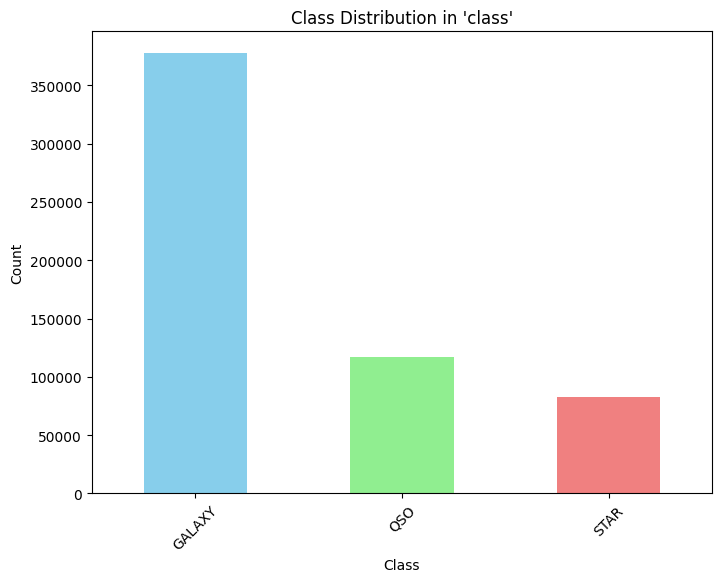

In [ ]:
def class_imbalance_check(df, target_col):
    '''Check for class imbalance in the target column of the dataframe.Accepts the dataframe and the name of the targer column as arguments.'''
    class_counts = df[target_col].value_counts()
    print(f"The class distribution in the target column '{target_col}' is:\n{class_counts}")
    #plot the class distribution as a bar chart using matplotlib
    #give the bars different colors
    #
    plt.figure(figsize=(8, 6))
    class_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
    plt.title(f"Class Distribution in '{target_col}'")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

traget_column = 'class'
class_imbalance_check(train_df, traget_column)